In [1]:
# 1 add libraries 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import seaborn as sns
sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# 2 select features for clustering
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

In [4]:
# 3 scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
# apply DBSCAN
dbscan = DBSCAN(eps=0.25, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

df['Cluster'] = labels
print('unique labels:', df['Cluster'].unique())
df.head()

unique labels: [-1  0  1  2  3  4  5]


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,-1
1,2,Male,21,15,81,0
2,3,Female,20,16,6,-1
3,4,Female,23,16,77,0
4,5,Female,31,17,40,-1


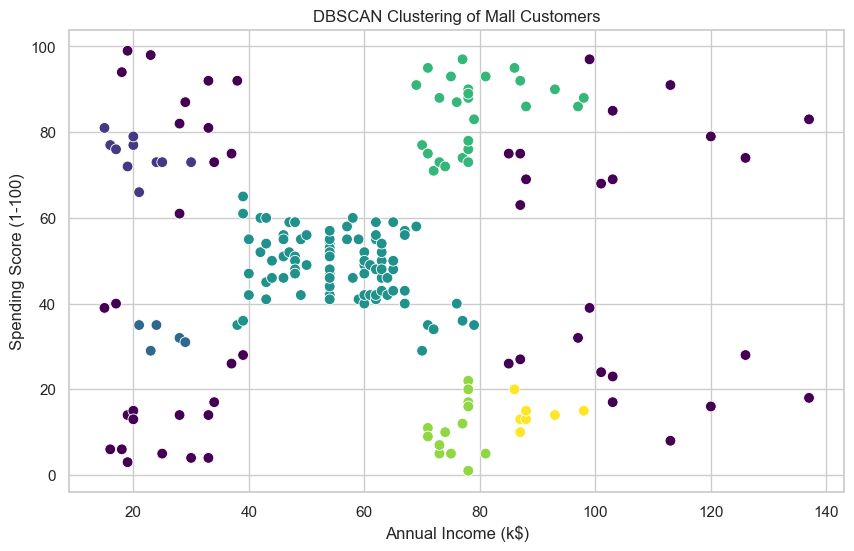

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Annual Income (k$)'],
                y=df['Spending Score (1-100)'],
                c =df['Cluster'],
                cmap='viridis',
                s=60)
plt.title('DBSCAN Clustering of Mall Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [10]:
# count each cluster
cluster_counts = df['Cluster'].value_counts()
print(cluster_counts)

Cluster
 2    87
-1    50
 3    27
 4    14
 0    10
 5     7
 1     5
Name: count, dtype: int64
